# Notebook 07: ML Pipeline

**Objetivo:** Clasificar experimentos por cluster usando Random Forest y XGBoost.

Dado que solo hay 17 muestras (16 vs 1 en el analisis original), se usa **Leave-One-Out CV** en lugar de k-Fold.

Se realizan dos analisis paralelos:
- **Original**: 17 experimentos, 2 clusters (Cluster 0 = 16 exp, Cluster 1 = Exp_9)
- **Refinado**: 15 experimentos sin Exp_9/Exp_11, 3 clusters (n=4, n=10, n=1)

In [1]:
# ============================================================
# IMPORTS Y CARGA DE DATOS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_predict, cross_validate
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, balanced_accuracy_score)
from sklearn.inspection import permutation_importance
import joblib

# XGBoost
try:
    from xgboost import XGBClassifier
    XGBOOST_OK = True
except ImportError:
    XGBOOST_OK = False
    print('XGBoost no disponible — solo se entrenara Random Forest')

# ── Cargar datos ──────────────────────────────────────────────────────────────
X_prep   = pd.read_csv('../data/processed/X_preprocessed.csv')
clusters = pd.read_csv('../data/processed/experiment_clusters.csv')

exp_cols = sorted([c for c in X_prep.columns if c.startswith('Exp_')],
                  key=lambda x: int(x.split('_')[1].split('.')[0]))
meta_cols = ['compound_name', 'hit_match_factor', 'match_quality', 'retention_time']

# Nombres de metabolitos (features)
feature_names = X_prep['compound_name'].tolist()

# ── Construir matrices ML ─────────────────────────────────────────────────────
# X_ml : (n_experimentos x n_metabolitos)  — filas = muestras
# y    : cluster label por experimento
X_matrix = X_prep[exp_cols].values          # 279 x 17
X_ml     = X_matrix.T                       # 17  x 279

exp_labels = [c.replace('.CDF', '') for c in exp_cols]
cluster_map = dict(zip(clusters['experiment'], clusters['cluster']))
y = np.array([cluster_map[e] for e in exp_labels])

print('=' * 90)
print('ML PIPELINE: CLASIFICACION DE EXPERIMENTOS POR CLUSTER')
print('=' * 90)
print(f'\nDATOS (analisis original):')
print(f'   X_ml shape : {X_ml.shape}  (experimentos x metabolitos)')
print(f'   y shape    : {y.shape}')
print(f'   Clases     : {np.unique(y)}')
print(f'   Distribucion:')
for c in np.unique(y):
    exps = [exp_labels[i] for i, yi in enumerate(y) if yi == c]
    print(f'     Cluster {c}: {len(exps)} exp -> {exps}')
print(f'\nNOTA: Con n=1 en Cluster 1, se usa Leave-One-Out CV.')

ML PIPELINE: CLASIFICACION DE EXPERIMENTOS POR CLUSTER

DATOS (analisis original):
   X_ml shape : (17, 279)  (experimentos x metabolitos)
   y shape    : (17,)
   Clases     : [0 1]
   Distribucion:
     Cluster 0: 16 exp -> ['Exp_1', 'Exp_2', 'Exp_3', 'Exp_4', 'Exp_5', 'Exp_6', 'Exp_7', 'Exp_8', 'Exp_10', 'Exp_11', 'Exp_12', 'Exp_13', 'Exp_14', 'Exp_15', 'Exp_16', 'Exp_17']
     Cluster 1: 1 exp -> ['Exp_9']

NOTA: Con n=1 en Cluster 1, se usa Leave-One-Out CV.


## 1. Random Forest — Analisis Original (17 experimentos)

In [2]:
# ============================================================
# RANDOM FOREST — LOO-CV (analisis original)
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',   # compensa el desbalance 16:1
    random_state=42,
    n_jobs=-1
)

print('=' * 90)
print('RANDOM FOREST — Leave-One-Out CV')
print('=' * 90)

# Leave-One-Out: unica opcion valida con n=17, minoritaria n=1
loo = LeaveOneOut()
y_pred_rf_loo = cross_val_predict(rf_model, X_ml, y, cv=loo)
y_proba_rf_loo = cross_val_predict(rf_model, X_ml, y, cv=loo, method='predict_proba')

acc_loo   = accuracy_score(y, y_pred_rf_loo)
bacc_loo  = balanced_accuracy_score(y, y_pred_rf_loo)

print(f'\nLOO-CV RESULTADOS:')
print(f'   Accuracy          : {acc_loo:.4f}  ({int(acc_loo*len(y))}/{len(y)} correctos)')
print(f'   Balanced Accuracy : {bacc_loo:.4f}')
print(f'\nClassification Report (LOO):')
print(classification_report(y, y_pred_rf_loo, target_names=['Cluster 0', 'Cluster 1']))

# Entrenar en datos completos para obtener feature importance
rf_model.fit(X_ml, y)

feat_imp_rf = pd.DataFrame({
    'metabolite': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print(f'TOP 15 METABOLITOS MAS IMPORTANTES (RF):')
for _, row in feat_imp_rf.head(15).iterrows():
    print(f'   {row["metabolite"][:55]:<55s}  {row["importance"]:.4f}')

# Guardar modelo y resultados
joblib.dump(rf_model, '../data/processed/07_rf_model.pkl')
feat_imp_rf.to_csv('../data/processed/07_rf_feature_importance.csv', index=False)
print('\nGuardado: 07_rf_model.pkl  |  07_rf_feature_importance.csv')

RANDOM FOREST — Leave-One-Out CV

LOO-CV RESULTADOS:
   Accuracy          : 0.9412  (16/17 correctos)
   Balanced Accuracy : 0.5000

Classification Report (LOO):
              precision    recall  f1-score   support

   Cluster 0       0.94      1.00      0.97        16
   Cluster 1       0.00      0.00      0.00         1

    accuracy                           0.94        17
   macro avg       0.47      0.50      0.48        17
weighted avg       0.89      0.94      0.91        17

TOP 15 METABOLITOS MAS IMPORTANTES (RF):
   Humulene                                                 0.0175
   Phenol                                                   0.0146
   2-Hexadecanone                                           0.0146
   Acetic acid ethenyl ester                                0.0146
   1,2,4-Metheno-1H-indene, octahydro-1,7a-dimethyl-5-(1-m  0.0146
   α-Cubebene                                               0.0117
   Benzeneacetic acid                                       0.0117
 

## 2. XGBoost — Analisis Original

In [4]:
# ============================================================
# XGBOOST — LOO-CV (analisis original)
# ============================================================

print('=' * 90)
print('XGBOOST — Leave-One-Out CV')
print('=' * 90)

if not XGBOOST_OK:
    print('XGBoost no instalado. Instalar con: pip install xgboost')
else:
    # scale_pos_weight compensa el desbalance 16:1
    n_neg = (y == 0).sum()
    n_pos = (y == 1).sum()
    spw   = n_neg / n_pos

    xgb_model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.5,
        scale_pos_weight=spw,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
        verbosity=0
    )

    # Solo predict (no predict_proba): con n_clase=1 en LOO, predict_proba falla
    # cuando el fold de test excluye la unica muestra de clase 1
    y_pred_xgb_loo = cross_val_predict(xgb_model, X_ml, y, cv=LeaveOneOut())

    acc_xgb  = accuracy_score(y, y_pred_xgb_loo)
    bacc_xgb = balanced_accuracy_score(y, y_pred_xgb_loo)

    print(f'\nLOO-CV RESULTADOS:')
    print(f'   Accuracy          : {acc_xgb:.4f}  ({int(acc_xgb*len(y))}/{len(y)} correctos)')
    print(f'   Balanced Accuracy : {bacc_xgb:.4f}')
    print(f'\nClassification Report (LOO):')
    print(classification_report(y, y_pred_xgb_loo, target_names=['Cluster 0', 'Cluster 1']))

    # Entrenar en datos completos
    xgb_model.fit(X_ml, y)

    feat_imp_xgb = pd.DataFrame({
        'metabolite': feature_names,
        'importance': xgb_model.feature_importances_
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    print(f'TOP 15 METABOLITOS MAS IMPORTANTES (XGB):')
    for _, row in feat_imp_xgb.head(15).iterrows():
        print(f'   {row["metabolite"][:55]:<55s}  {row["importance"]:.4f}')

    joblib.dump(xgb_model, '../data/processed/07_xgb_model.pkl')
    feat_imp_xgb.to_csv('../data/processed/07_xgb_feature_importance.csv', index=False)
    print('\nGuardado: 07_xgb_model.pkl  |  07_xgb_feature_importance.csv')

XGBOOST — Leave-One-Out CV

LOO-CV RESULTADOS:
   Accuracy          : 0.8824  (15/17 correctos)
   Balanced Accuracy : 0.4688

Classification Report (LOO):
              precision    recall  f1-score   support

   Cluster 0       0.94      0.94      0.94        16
   Cluster 1       0.00      0.00      0.00         1

    accuracy                           0.88        17
   macro avg       0.47      0.47      0.47        17
weighted avg       0.88      0.88      0.88        17

TOP 15 METABOLITOS MAS IMPORTANTES (XGB):
   Acetic acid ethenyl ester                                0.3288
   1,3-Dioxolane                                            0.2593
   2-Propenal                                               0.1218
   2-Propenal                                               0.0745
   Acetone                                                  0.0745
   2-Propenal                                               0.0733
   Acetone                                                  0.0413
   1,3

## 3. Visualizaciones — Analisis Original

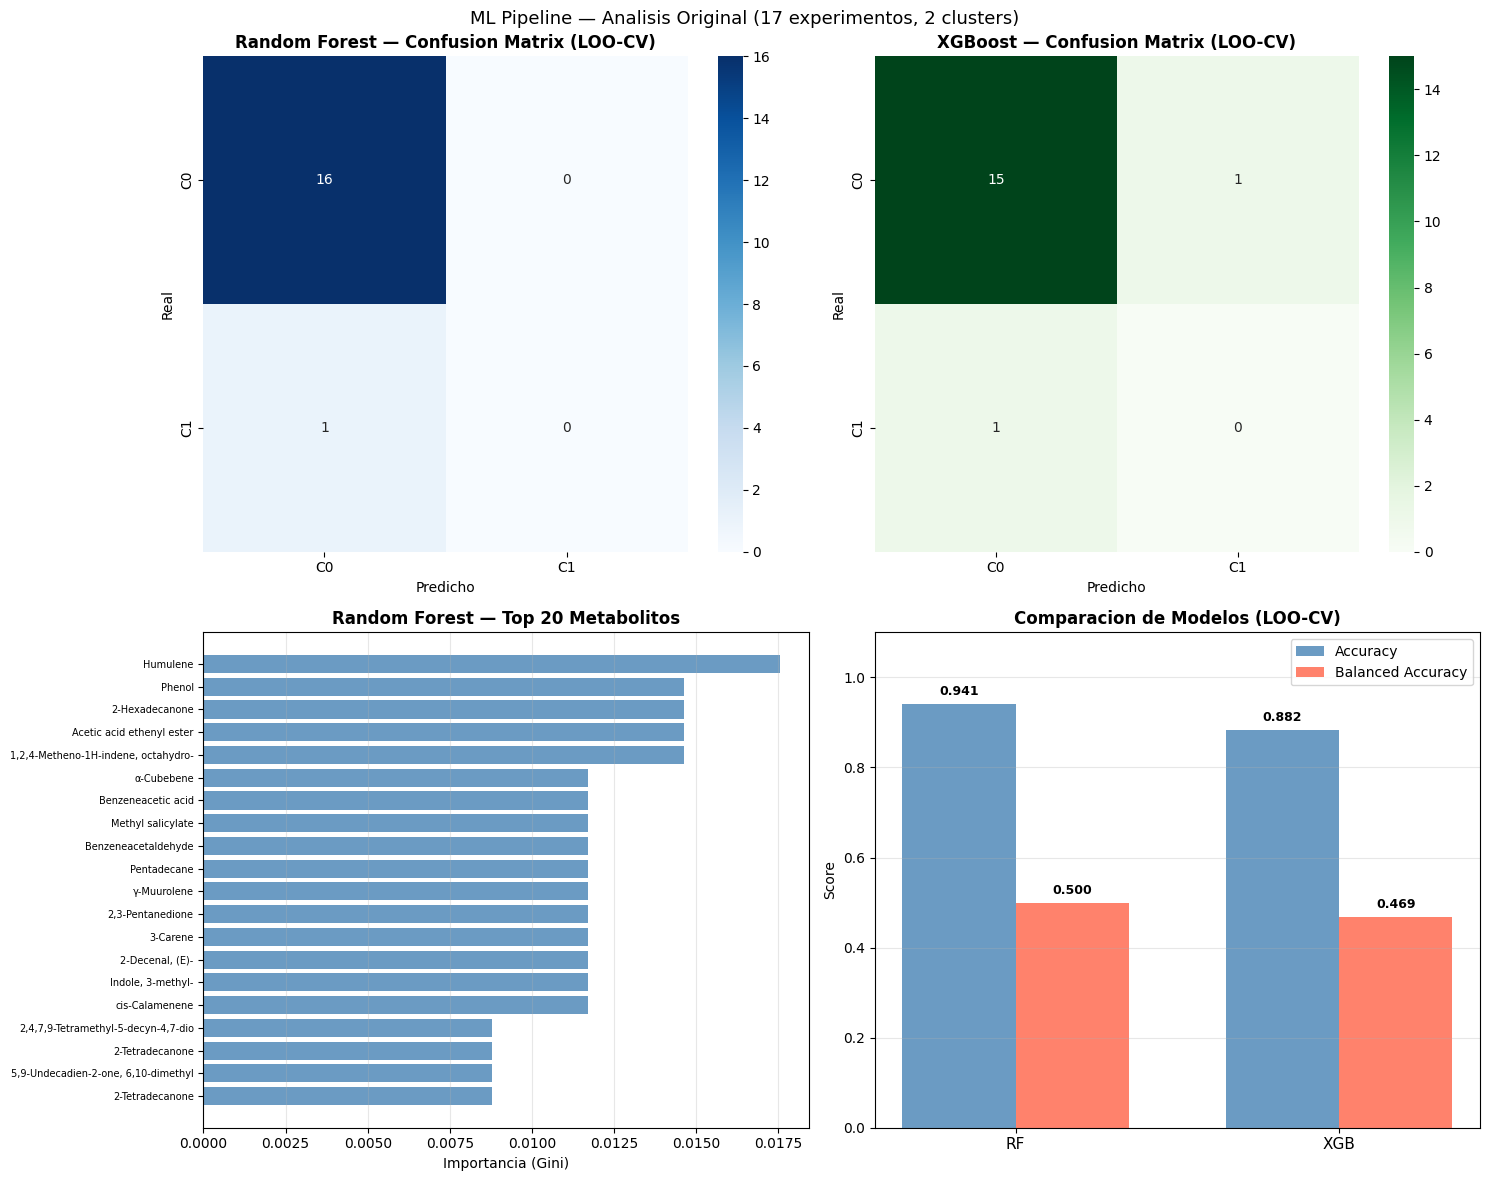

Guardado: 07_ml_original.png


In [5]:
# ============================================================
# VISUALIZACIONES — ANALISIS ORIGINAL
# ============================================================

n_models = 2 if XGBOOST_OK else 1
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('ML Pipeline — Analisis Original (17 experimentos, 2 clusters)', fontsize=13)

# Plot 1: Confusion Matrix RF
ax = axes[0, 0]
cm_rf = confusion_matrix(y, y_pred_rf_loo)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['C0', 'C1'], yticklabels=['C0', 'C1'])
ax.set_title('Random Forest — Confusion Matrix (LOO-CV)', fontweight='bold')
ax.set_ylabel('Real')
ax.set_xlabel('Predicho')

# Plot 2: Confusion Matrix XGB
ax2 = axes[0, 1]
if XGBOOST_OK:
    cm_xgb = confusion_matrix(y, y_pred_xgb_loo)
    sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=ax2,
                xticklabels=['C0', 'C1'], yticklabels=['C0', 'C1'])
    ax2.set_title('XGBoost — Confusion Matrix (LOO-CV)', fontweight='bold')
    ax2.set_ylabel('Real')
    ax2.set_xlabel('Predicho')
else:
    ax2.text(0.5, 0.5, 'XGBoost no disponible', ha='center', va='center', fontsize=12)
    ax2.axis('off')

# Plot 3: Feature importance RF (top 20)
ax3 = axes[1, 0]
top20_rf = feat_imp_rf.head(20).iloc[::-1]
bars = ax3.barh(range(len(top20_rf)), top20_rf['importance'], color='steelblue', alpha=0.8)
ax3.set_yticks(range(len(top20_rf)))
ax3.set_yticklabels(top20_rf['metabolite'].str[:35], fontsize=7)
ax3.set_xlabel('Importancia (Gini)')
ax3.set_title('Random Forest — Top 20 Metabolitos', fontweight='bold')
ax3.grid(alpha=0.3, axis='x')

# Plot 4: Comparacion de modelos
ax4 = axes[1, 1]
model_names = ['RF']
accs  = [acc_loo]
baccs = [bacc_loo]
if XGBOOST_OK:
    model_names.append('XGB')
    accs.append(acc_xgb)
    baccs.append(bacc_xgb)

x = np.arange(len(model_names))
w = 0.35
ax4.bar(x - w/2, accs,  w, label='Accuracy',          color='steelblue', alpha=0.8)
ax4.bar(x + w/2, baccs, w, label='Balanced Accuracy',  color='tomato',    alpha=0.8)
ax4.set_xticks(x)
ax4.set_xticklabels(model_names, fontsize=11)
ax4.set_ylim(0, 1.1)
ax4.set_ylabel('Score')
ax4.set_title('Comparacion de Modelos (LOO-CV)', fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3, axis='y')
for i, (a, b) in enumerate(zip(accs, baccs)):
    ax4.text(i - w/2, a + 0.02, f'{a:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax4.text(i + w/2, b + 0.02, f'{b:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/07_ml_original.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: 07_ml_original.png')

## 4. SHAP — Analisis Original

SHAP FEATURE IMPORTANCE — Random Forest (analisis original)
TOP 15 METABOLITOS POR SHAP (Cluster 1 = outlier):
   Humulene                                                 0.0068
   Phenol                                                   0.0063
   Acetic acid ethenyl ester                                0.0060
   2-Hexadecanone                                           0.0055
   1,2,4-Metheno-1H-indene, octahydro-1,7a-dimethyl-5-(1-m  0.0053
   Benzeneacetaldehyde                                      0.0051
   cis-Calamenene                                           0.0050
   Indole, 3-methyl-                                        0.0050
   γ-Muurolene                                              0.0046
   2,3-Pentanedione                                         0.0046
   Hexanoic acid, 2-ethyl-                                  0.0044
   Methyl salicylate                                        0.0043
   Benzeneacetic acid                                       0.0043
   Pentadecane    

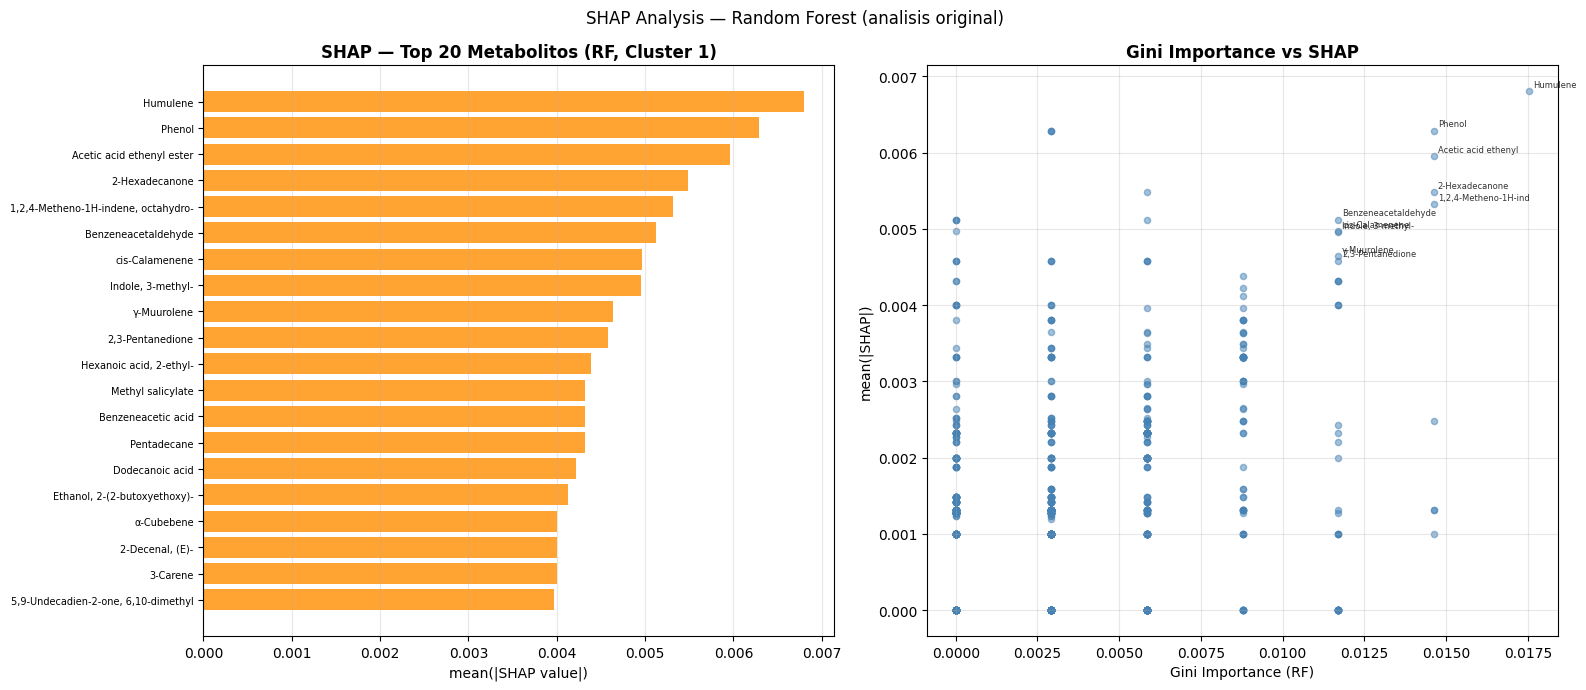


Guardado: 07_shap_original.png  |  07_shap_importance.csv


In [6]:
# ============================================================
# SHAP — ANALISIS ORIGINAL
# TreeExplainer sobre el RF entrenado con todos los datos.
# Permite identificar que metabolitos "empujan" hacia cada cluster.
# ============================================================

try:
    import shap
    SHAP_OK = True
except ImportError:
    SHAP_OK = False
    print('SHAP no instalado. Instalar con: pip install shap')

if SHAP_OK:
    print('=' * 90)
    print('SHAP FEATURE IMPORTANCE — Random Forest (analisis original)')
    print('=' * 90)

    explainer_rf = shap.TreeExplainer(rf_model)
    shap_values_rf = explainer_rf.shap_values(X_ml)

    # shap_values_rf es lista [clase0, clase1] o array 3D segun version
    if isinstance(shap_values_rf, list):
        sv_class1 = shap_values_rf[1]   # valores SHAP para Cluster 1 (outlier)
    else:
        sv_class1 = shap_values_rf[:, :, 1]

    # Importancia SHAP media por metabolito (|SHAP|)
    shap_imp = pd.DataFrame({
        'metabolite': feature_names,
        'shap_mean_abs': np.abs(sv_class1).mean(axis=0)
    }).sort_values('shap_mean_abs', ascending=False).reset_index(drop=True)

    print(f'TOP 15 METABOLITOS POR SHAP (Cluster 1 = outlier):')
    for _, row in shap_imp.head(15).iterrows():
        print(f'   {row["metabolite"][:55]:<55s}  {row["shap_mean_abs"]:.4f}')

    shap_imp.to_csv('../data/processed/07_shap_importance.csv', index=False)

    # Visualizacion
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Barplot SHAP top 20
    ax = axes[0]
    top20_shap = shap_imp.head(20).iloc[::-1]
    ax.barh(range(len(top20_shap)), top20_shap['shap_mean_abs'],
            color='darkorange', alpha=0.8, edgecolor='none')
    ax.set_yticks(range(len(top20_shap)))
    ax.set_yticklabels(top20_shap['metabolite'].str[:35], fontsize=7)
    ax.set_xlabel('mean(|SHAP value|)')
    ax.set_title('SHAP — Top 20 Metabolitos (RF, Cluster 1)', fontweight='bold')
    ax.grid(alpha=0.3, axis='x')

    # Scatter SHAP vs Gini importance
    ax2 = axes[1]
    merged = feat_imp_rf.merge(shap_imp, on='metabolite')
    ax2.scatter(merged['importance'], merged['shap_mean_abs'],
                alpha=0.5, s=20, color='steelblue')
    # Anotar top 10 por SHAP
    for _, row in shap_imp.head(10).iterrows():
        m = merged[merged['metabolite'] == row['metabolite']]
        if len(m):
            ax2.annotate(row['metabolite'][:20],
                         (m['importance'].values[0], m['shap_mean_abs'].values[0]),
                         fontsize=6, alpha=0.8,
                         xytext=(3, 3), textcoords='offset points')
    ax2.set_xlabel('Gini Importance (RF)')
    ax2.set_ylabel('mean(|SHAP|)')
    ax2.set_title('Gini Importance vs SHAP', fontweight='bold')
    ax2.grid(alpha=0.3)

    plt.suptitle('SHAP Analysis — Random Forest (analisis original)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../results/figures/07_shap_original.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('\nGuardado: 07_shap_original.png  |  07_shap_importance.csv')

---

## ANALISIS REFINADO: ML sin Exp_9 ni Exp_11

> Se usan los 3 clusters del analisis refinado (n=4, n=10, n=1). Se aplica LOO-CV para los 15 experimentos.

In [7]:
# ============================================================
# CARGA — ANALISIS REFINADO (sin Exp_9 ni Exp_11)
# ============================================================

clusters_no_out = pd.read_csv('../data/processed/experiment_clusters_no_outlier.csv')
EXCLUIDOS = ['Exp_9', 'Exp_11']

# Filtrar columnas y experimentos
exp_cols_no_out = [c for c in exp_cols
                   if c.replace('.CDF', '') not in EXCLUIDOS]
exp_labels_no_out = [c.replace('.CDF', '') for c in exp_cols_no_out]

X_matrix_no_out = X_prep[exp_cols_no_out].values     # 279 x 15
X_ml_no_out     = X_matrix_no_out.T                  # 15  x 279

cluster_map_no_out = dict(zip(clusters_no_out['experiment'], clusters_no_out['cluster']))
y_no_out = np.array([cluster_map_no_out[e] for e in exp_labels_no_out])

print('=' * 90)
print('ML PIPELINE — ANALISIS REFINADO (sin Exp_9 ni Exp_11)')
print('=' * 90)
print(f'\nDATOS:')
print(f'   X_ml shape : {X_ml_no_out.shape}  (experimentos x metabolitos)')
print(f'   Clases     : {np.unique(y_no_out)}')
print(f'   Distribucion:')
for c in np.unique(y_no_out):
    exps = [exp_labels_no_out[i] for i, yi in enumerate(y_no_out) if yi == c]
    print(f'     Cluster {c}: {len(exps)} exp -> {exps}')

ML PIPELINE — ANALISIS REFINADO (sin Exp_9 ni Exp_11)

DATOS:
   X_ml shape : (15, 279)  (experimentos x metabolitos)
   Clases     : [0 1 2]
   Distribucion:
     Cluster 0: 4 exp -> ['Exp_1', 'Exp_2', 'Exp_3', 'Exp_4']
     Cluster 1: 10 exp -> ['Exp_5', 'Exp_6', 'Exp_7', 'Exp_10', 'Exp_12', 'Exp_13', 'Exp_14', 'Exp_15', 'Exp_16', 'Exp_17']
     Cluster 2: 1 exp -> ['Exp_8']


In [8]:
# ============================================================
# RANDOM FOREST — LOO-CV (analisis refinado, 3 clases)
# ============================================================

rf_no_out = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print('=' * 90)
print('RANDOM FOREST — LOO-CV (sin Exp_9 ni Exp_11, 3 clusters)')
print('=' * 90)

loo_no_out = LeaveOneOut()
y_pred_rf_no_out = cross_val_predict(rf_no_out, X_ml_no_out, y_no_out, cv=loo_no_out)

acc_no_out  = accuracy_score(y_no_out, y_pred_rf_no_out)
bacc_no_out = balanced_accuracy_score(y_no_out, y_pred_rf_no_out)

print(f'\nLOO-CV RESULTADOS:')
print(f'   Accuracy          : {acc_no_out:.4f}  ({int(acc_no_out*len(y_no_out))}/{len(y_no_out)} correctos)')
print(f'   Balanced Accuracy : {bacc_no_out:.4f}')
print(f'\nClassification Report (LOO):')
print(classification_report(y_no_out, y_pred_rf_no_out,
                             target_names=['Cluster 0', 'Cluster 1', 'Cluster 2']))

# Entrenar en datos completos
rf_no_out.fit(X_ml_no_out, y_no_out)

feat_imp_rf_no_out = pd.DataFrame({
    'metabolite': feature_names,
    'importance': rf_no_out.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print(f'TOP 15 METABOLITOS MAS IMPORTANTES (RF, refinado):')
for _, row in feat_imp_rf_no_out.head(15).iterrows():
    print(f'   {row["metabolite"][:55]:<55s}  {row["importance"]:.4f}')

joblib.dump(rf_no_out, '../data/processed/07_rf_model_no_outlier.pkl')
feat_imp_rf_no_out.to_csv('../data/processed/07_rf_feature_importance_no_outlier.csv', index=False)
print('\nGuardado: 07_rf_model_no_outlier.pkl  |  07_rf_feature_importance_no_outlier.csv')

RANDOM FOREST — LOO-CV (sin Exp_9 ni Exp_11, 3 clusters)

LOO-CV RESULTADOS:
   Accuracy          : 0.8667  (13/15 correctos)
   Balanced Accuracy : 0.5833

Classification Report (LOO):
              precision    recall  f1-score   support

   Cluster 0       1.00      0.75      0.86         4
   Cluster 1       0.83      1.00      0.91        10
   Cluster 2       0.00      0.00      0.00         1

    accuracy                           0.87        15
   macro avg       0.61      0.58      0.59        15
weighted avg       0.82      0.87      0.83        15

TOP 15 METABOLITOS MAS IMPORTANTES (RF, refinado):
   2-Nonanone                                               0.0173
   Phenylethyl Alcohol                                      0.0147
   p-Cresol                                                 0.0146
   n-Decanoic acid                                          0.0143
   Dodecane, 2,6,10-trimethyl-                              0.0128
   Indole                                      

In [9]:
# ============================================================
# XGBOOST — LOO-CV (analisis refinado, 3 clases)
# ============================================================

print('=' * 90)
print('XGBOOST — LOO-CV (sin Exp_9 ni Exp_11, 3 clusters)')
print('=' * 90)

if not XGBOOST_OK:
    print('XGBoost no disponible.')
else:
    xgb_no_out = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.5,
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss',
        verbosity=0
    )

    # Solo predict: mismo problema que en el original con clase minoritaria n=1
    y_pred_xgb_no_out = cross_val_predict(xgb_no_out, X_ml_no_out, y_no_out,
                                          cv=LeaveOneOut())

    acc_xgb_no_out  = accuracy_score(y_no_out, y_pred_xgb_no_out)
    bacc_xgb_no_out = balanced_accuracy_score(y_no_out, y_pred_xgb_no_out)

    print(f'\nLOO-CV RESULTADOS:')
    print(f'   Accuracy          : {acc_xgb_no_out:.4f}  ({int(acc_xgb_no_out*len(y_no_out))}/{len(y_no_out)} correctos)')
    print(f'   Balanced Accuracy : {bacc_xgb_no_out:.4f}')
    print(f'\nClassification Report (LOO):')
    print(classification_report(y_no_out, y_pred_xgb_no_out,
                                 target_names=['Cluster 0', 'Cluster 1', 'Cluster 2']))

    xgb_no_out.fit(X_ml_no_out, y_no_out)

    feat_imp_xgb_no_out = pd.DataFrame({
        'metabolite': feature_names,
        'importance': xgb_no_out.feature_importances_
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    print(f'TOP 15 METABOLITOS MAS IMPORTANTES (XGB, refinado):')
    for _, row in feat_imp_xgb_no_out.head(15).iterrows():
        print(f'   {row["metabolite"][:55]:<55s}  {row["importance"]:.4f}')

    joblib.dump(xgb_no_out, '../data/processed/07_xgb_model_no_outlier.pkl')
    feat_imp_xgb_no_out.to_csv('../data/processed/07_xgb_feature_importance_no_outlier.csv', index=False)
    print('\nGuardado: 07_xgb_model_no_outlier.pkl  |  07_xgb_feature_importance_no_outlier.csv')

XGBOOST — LOO-CV (sin Exp_9 ni Exp_11, 3 clusters)

LOO-CV RESULTADOS:
   Accuracy          : 0.8000  (12/15 correctos)
   Balanced Accuracy : 0.5500

Classification Report (LOO):
              precision    recall  f1-score   support

   Cluster 0       0.75      0.75      0.75         4
   Cluster 1       0.82      0.90      0.86        10
   Cluster 2       0.00      0.00      0.00         1

    accuracy                           0.80        15
   macro avg       0.52      0.55      0.54        15
weighted avg       0.75      0.80      0.77        15

TOP 15 METABOLITOS MAS IMPORTANTES (XGB, refinado):
   2-Propenal                                               0.0663
   cis-Calamenene                                           0.0585
   Methional                                                0.0575
   N-Dimethylaminomethyl-tert.-butyl-isopropylphosphine     0.0565
   Propanal, 2-methyl-                                      0.0505
   2-Propenal                                       

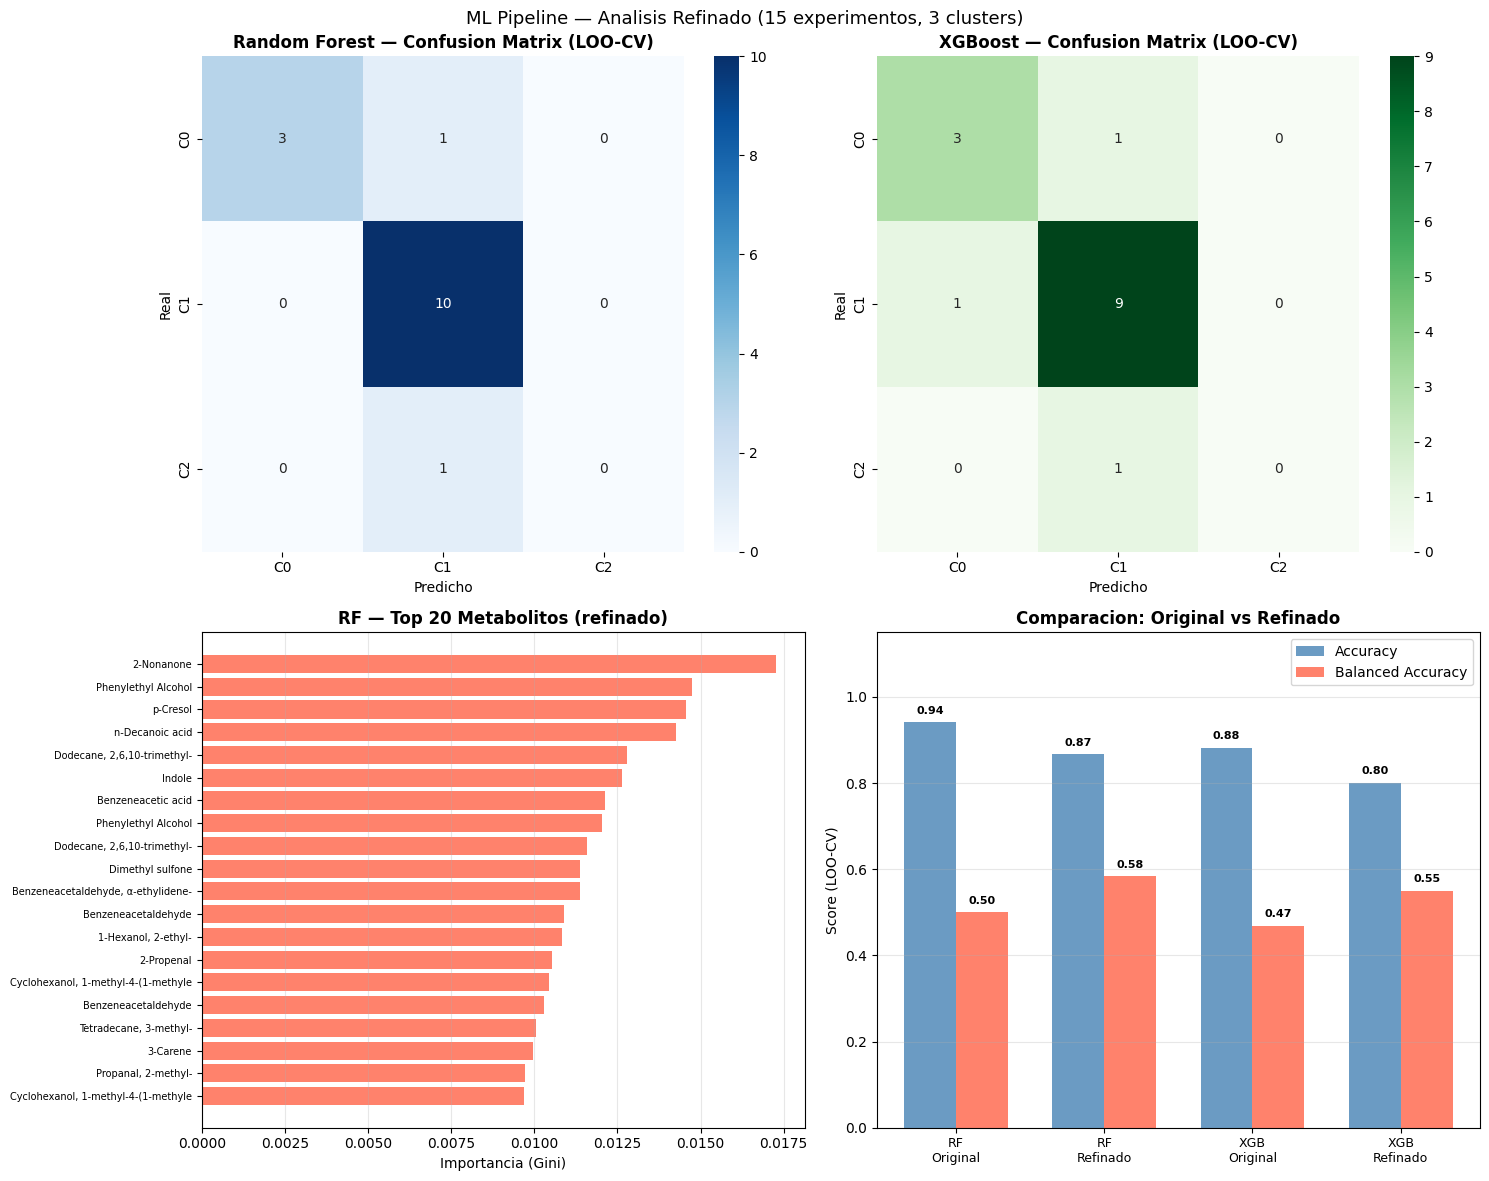

Guardado: 07_ml_no_outlier.png


In [10]:
# ============================================================
# VISUALIZACIONES — ANALISIS REFINADO
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('ML Pipeline — Analisis Refinado (15 experimentos, 3 clusters)', fontsize=13)

# Plot 1: Confusion Matrix RF refinado
ax = axes[0, 0]
cm_rf_no_out = confusion_matrix(y_no_out, y_pred_rf_no_out)
sns.heatmap(cm_rf_no_out, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['C0', 'C1', 'C2'], yticklabels=['C0', 'C1', 'C2'])
ax.set_title('Random Forest — Confusion Matrix (LOO-CV)', fontweight='bold')
ax.set_ylabel('Real')
ax.set_xlabel('Predicho')

# Plot 2: Confusion Matrix XGB refinado
ax2 = axes[0, 1]
if XGBOOST_OK:
    cm_xgb_no_out = confusion_matrix(y_no_out, y_pred_xgb_no_out)
    sns.heatmap(cm_xgb_no_out, annot=True, fmt='d', cmap='Greens', ax=ax2,
                xticklabels=['C0', 'C1', 'C2'], yticklabels=['C0', 'C1', 'C2'])
    ax2.set_title('XGBoost — Confusion Matrix (LOO-CV)', fontweight='bold')
    ax2.set_ylabel('Real')
    ax2.set_xlabel('Predicho')
else:
    ax2.text(0.5, 0.5, 'XGBoost no disponible', ha='center', va='center', fontsize=12)
    ax2.axis('off')

# Plot 3: Feature importance RF refinado (top 20)
ax3 = axes[1, 0]
top20_rf_no_out = feat_imp_rf_no_out.head(20).iloc[::-1]
ax3.barh(range(len(top20_rf_no_out)), top20_rf_no_out['importance'],
         color='tomato', alpha=0.8, edgecolor='none')
ax3.set_yticks(range(len(top20_rf_no_out)))
ax3.set_yticklabels(top20_rf_no_out['metabolite'].str[:35], fontsize=7)
ax3.set_xlabel('Importancia (Gini)')
ax3.set_title('RF — Top 20 Metabolitos (refinado)', fontweight='bold')
ax3.grid(alpha=0.3, axis='x')

# Plot 4: Comparacion original vs refinado
ax4 = axes[1, 1]
labels_comp = ['RF\nOriginal', 'RF\nRefinado']
accs_comp  = [acc_loo,   acc_no_out]
baccs_comp = [bacc_loo,  bacc_no_out]
if XGBOOST_OK:
    labels_comp += ['XGB\nOriginal', 'XGB\nRefinado']
    accs_comp   += [acc_xgb,         acc_xgb_no_out]
    baccs_comp  += [bacc_xgb,        bacc_xgb_no_out]

x = np.arange(len(labels_comp))
w = 0.35
ax4.bar(x - w/2, accs_comp,  w, label='Accuracy',         color='steelblue', alpha=0.8)
ax4.bar(x + w/2, baccs_comp, w, label='Balanced Accuracy', color='tomato',    alpha=0.8)
ax4.set_xticks(x)
ax4.set_xticklabels(labels_comp, fontsize=9)
ax4.set_ylim(0, 1.15)
ax4.set_ylabel('Score (LOO-CV)')
ax4.set_title('Comparacion: Original vs Refinado', fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3, axis='y')
for i, (a, b) in enumerate(zip(accs_comp, baccs_comp)):
    ax4.text(i - w/2, a + 0.02, f'{a:.2f}', ha='center', fontsize=8, fontweight='bold')
    ax4.text(i + w/2, b + 0.02, f'{b:.2f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/07_ml_no_outlier.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: 07_ml_no_outlier.png')

SHAP — Random Forest (analisis refinado, 3 clusters)
TOP 15 POR SHAP (media entre las 3 clases):
   2-Nonanone                                               0.0071
   Dodecane, 2,6,10-trimethyl-                              0.0062
   Dimethyl sulfone                                         0.0061
   Dodecane, 2,6,10-trimethyl-                              0.0059
   p-Cresol                                                 0.0057
   Benzeneacetaldehyde                                      0.0057
   Phenylethyl Alcohol                                      0.0056
   Indole                                                   0.0054
   n-Decanoic acid                                          0.0054
   cis-Calamenene                                           0.0053
   Phenylethyl Alcohol                                      0.0051
   Cyclohexanol, 1-methyl-4-(1-methylethenyl)-, acetate     0.0051
   3-Carene                                                 0.0049
   Benzeneacetaldehyde, α-ethyli

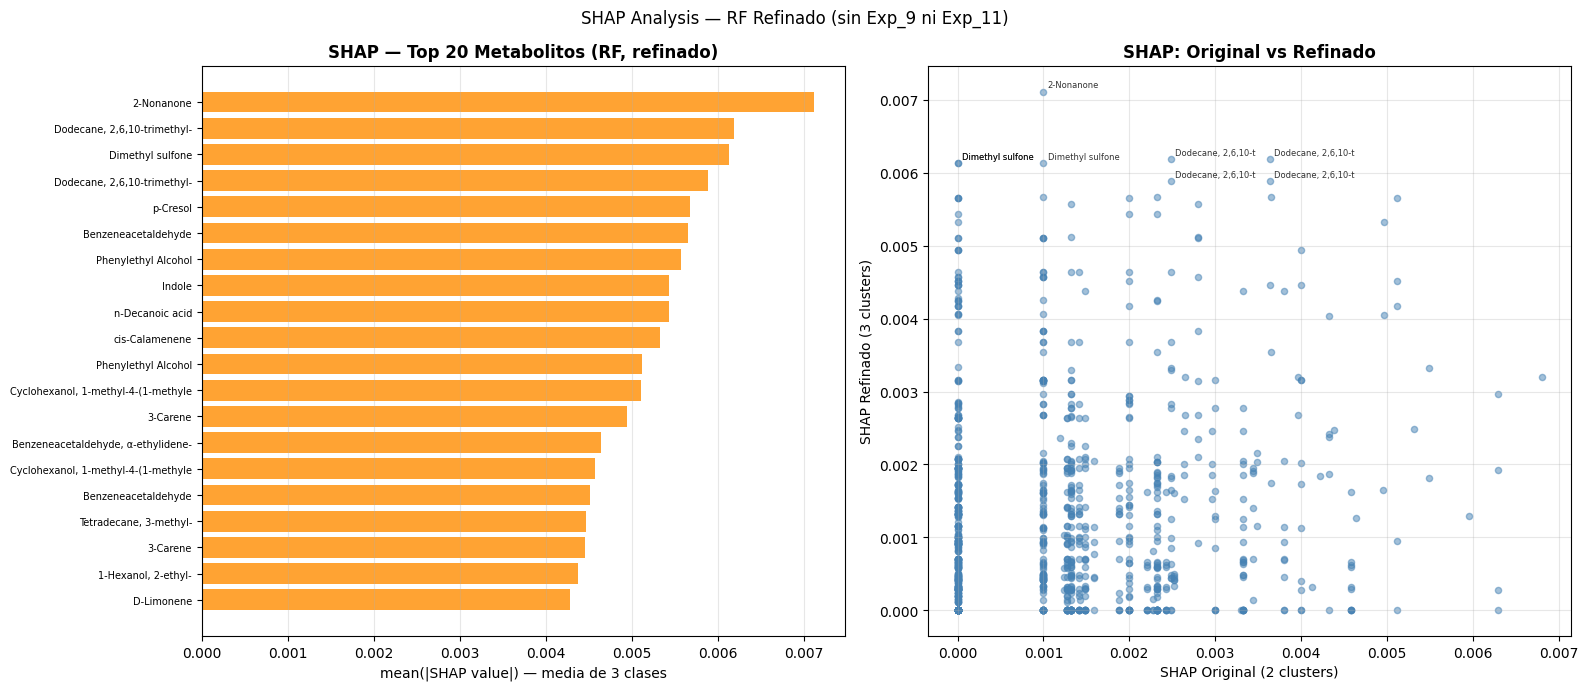


Guardado: 07_shap_no_outlier.png  |  07_shap_importance_no_outlier.csv


In [11]:
# ============================================================
# SHAP — ANALISIS REFINADO (RF, 3 clases)
# ============================================================

if SHAP_OK:
    print('=' * 90)
    print('SHAP — Random Forest (analisis refinado, 3 clusters)')
    print('=' * 90)

    explainer_no_out = shap.TreeExplainer(rf_no_out)
    shap_values_no_out = explainer_no_out.shap_values(X_ml_no_out)

    # Importancia media entre todas las clases
    if isinstance(shap_values_no_out, list):
        sv_all = np.stack([np.abs(sv) for sv in shap_values_no_out], axis=0).mean(axis=0)
    else:
        sv_all = np.abs(shap_values_no_out).mean(axis=2)

    shap_imp_no_out = pd.DataFrame({
        'metabolite'  : feature_names,
        'shap_mean_abs': sv_all.mean(axis=0)
    }).sort_values('shap_mean_abs', ascending=False).reset_index(drop=True)

    print(f'TOP 15 POR SHAP (media entre las 3 clases):')
    for _, row in shap_imp_no_out.head(15).iterrows():
        print(f'   {row["metabolite"][:55]:<55s}  {row["shap_mean_abs"]:.4f}')

    shap_imp_no_out.to_csv('../data/processed/07_shap_importance_no_outlier.csv', index=False)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    ax = axes[0]
    top20_shap_no_out = shap_imp_no_out.head(20).iloc[::-1]
    ax.barh(range(len(top20_shap_no_out)), top20_shap_no_out['shap_mean_abs'],
            color='darkorange', alpha=0.8, edgecolor='none')
    ax.set_yticks(range(len(top20_shap_no_out)))
    ax.set_yticklabels(top20_shap_no_out['metabolite'].str[:35], fontsize=7)
    ax.set_xlabel('mean(|SHAP value|) — media de 3 clases')
    ax.set_title('SHAP — Top 20 Metabolitos (RF, refinado)', fontweight='bold')
    ax.grid(alpha=0.3, axis='x')

    # Comparacion SHAP original vs refinado
    ax2 = axes[1]
    shap_comp = shap_imp.rename(columns={'shap_mean_abs': 'shap_orig'}).merge(
        shap_imp_no_out.rename(columns={'shap_mean_abs': 'shap_no_out'}),
        on='metabolite'
    )
    ax2.scatter(shap_comp['shap_orig'], shap_comp['shap_no_out'],
                alpha=0.5, s=20, color='steelblue')
    for _, row in shap_comp.sort_values('shap_no_out', ascending=False).head(8).iterrows():
        ax2.annotate(row['metabolite'][:18],
                     (row['shap_orig'], row['shap_no_out']),
                     fontsize=6, alpha=0.8,
                     xytext=(3, 3), textcoords='offset points')
    ax2.set_xlabel('SHAP Original (2 clusters)')
    ax2.set_ylabel('SHAP Refinado (3 clusters)')
    ax2.set_title('SHAP: Original vs Refinado', fontweight='bold')
    ax2.grid(alpha=0.3)

    plt.suptitle('SHAP Analysis — RF Refinado (sin Exp_9 ni Exp_11)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../results/figures/07_shap_no_outlier.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('\nGuardado: 07_shap_no_outlier.png  |  07_shap_importance_no_outlier.csv')

In [12]:
# ============================================================
# RESUMEN FINAL — NOTEBOOK 07
# ============================================================
import os

print('=' * 90)
print('RESUMEN FINAL: ML PIPELINE')
print('=' * 90)

acc_xgb_str     = f'{acc_xgb:.4f}' if XGBOOST_OK else 'N/A'
bacc_xgb_str    = f'{bacc_xgb:.4f}' if XGBOOST_OK else 'N/A'
acc_xgb_no_str  = f'{acc_xgb_no_out:.4f}' if XGBOOST_OK else 'N/A'
bacc_xgb_no_str = f'{bacc_xgb_no_out:.4f}' if XGBOOST_OK else 'N/A'

print(f"""
NOTEBOOK 07 - ML PIPELINE
===========================
  Metodo de validacion : Leave-One-Out CV (LOO)
  Features             : {len(feature_names)} metabolitos
  Modelos              : Random Forest  |  XGBoost

  ANALISIS ORIGINAL (17 exp, 2 clusters)
  {"Modelo":<15s}  {"Accuracy":>10s}  {"Bal.Acc.":>10s}
  {"-"*40}
  {"Random Forest":<15s}  {acc_loo:>10.4f}  {bacc_loo:>10.4f}
  {"XGBoost":<15s}  {acc_xgb_str:>10s}  {bacc_xgb_str:>10s}

  ANALISIS REFINADO (15 exp, 3 clusters, sin Exp_9/11)
  {"Modelo":<15s}  {"Accuracy":>10s}  {"Bal.Acc.":>10s}
  {"-"*40}
  {"Random Forest":<15s}  {acc_no_out:>10.4f}  {bacc_no_out:>10.4f}
  {"XGBoost":<15s}  {acc_xgb_no_str:>10s}  {bacc_xgb_no_str:>10s}

  ARCHIVOS GENERADOS (original)
  data/processed/07_rf_model.pkl
  data/processed/07_rf_feature_importance.csv
  data/processed/07_xgb_model.pkl             (si XGBoost disponible)
  data/processed/07_xgb_feature_importance.csv
  data/processed/07_shap_importance.csv        (si SHAP disponible)

  ARCHIVOS GENERADOS (refinado)
  data/processed/07_rf_model_no_outlier.pkl
  data/processed/07_rf_feature_importance_no_outlier.csv
  data/processed/07_xgb_model_no_outlier.pkl
  data/processed/07_xgb_feature_importance_no_outlier.csv
  data/processed/07_shap_importance_no_outlier.csv

  FIGURAS
  results/figures/07_ml_original.png
  results/figures/07_ml_no_outlier.png
  results/figures/07_shap_original.png         (si SHAP disponible)
  results/figures/07_shap_no_outlier.png       (si SHAP disponible)

  SIGUIENTE PASO -> Notebook 08: Interpretation & Biomarkers
""")

outputs_07 = [
    '../data/processed/07_rf_model.pkl',
    '../data/processed/07_rf_feature_importance.csv',
    '../data/processed/07_rf_model_no_outlier.pkl',
    '../data/processed/07_rf_feature_importance_no_outlier.csv',
    '../results/figures/07_ml_original.png',
    '../results/figures/07_ml_no_outlier.png',
]
print('VERIFICACION DE ARCHIVOS:')
for f in outputs_07:
    exists = os.path.exists(f)
    status = 'OK  ' if exists else 'FALTA'
    size   = f'{os.path.getsize(f)/1024:.1f} KB' if exists else ''
    print(f'   [{status}]  {f}  {size}')

RESUMEN FINAL: ML PIPELINE

NOTEBOOK 07 - ML PIPELINE
  Metodo de validacion : Leave-One-Out CV (LOO)
  Features             : 279 metabolitos
  Modelos              : Random Forest  |  XGBoost

  ANALISIS ORIGINAL (17 exp, 2 clusters)
  Modelo             Accuracy    Bal.Acc.
  ----------------------------------------
  Random Forest        0.9412      0.5000
  XGBoost              0.8824      0.4688

  ANALISIS REFINADO (15 exp, 3 clusters, sin Exp_9/11)
  Modelo             Accuracy    Bal.Acc.
  ----------------------------------------
  Random Forest        0.8667      0.5833
  XGBoost              0.8000      0.5500

  ARCHIVOS GENERADOS (original)
  data/processed/07_rf_model.pkl
  data/processed/07_rf_feature_importance.csv
  data/processed/07_xgb_model.pkl             (si XGBoost disponible)
  data/processed/07_xgb_feature_importance.csv
  data/processed/07_shap_importance.csv        (si SHAP disponible)

  ARCHIVOS GENERADOS (refinado)
  data/processed/07_rf_model_no_outlier.